# Geographic Distribution of Dataset Locations

This notebook visualizes the spatial distribution of locations in the balanced dataset on a world map.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Try to use cartopy for better map projections, fallback to simple scatter if not available
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("Cartopy not available. Using simple scatter plot.")
    print("Install with: pip install cartopy")


In [2]:
# Load dataset
csv_path = "../data/6921d7831744c5356b098bf7_balanced/dataset.csv"
df = pd.read_csv(csv_path)

print(f"Total locations: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

# Filter out missing coordinates
df_clean = df.dropna(subset=['lat', 'lng'])
print(f"Locations with valid coordinates: {len(df_clean):,}")

# Extract coordinates
lats = df_clean['lat'].values
lngs = df_clean['lng'].values


Total locations: 42,536
Columns: ['image_path', 'pano_id', 'country', 'lat', 'lng', 'meta_name', 'note', 'footer', 'images']
Locations with valid coordinates: 42,536


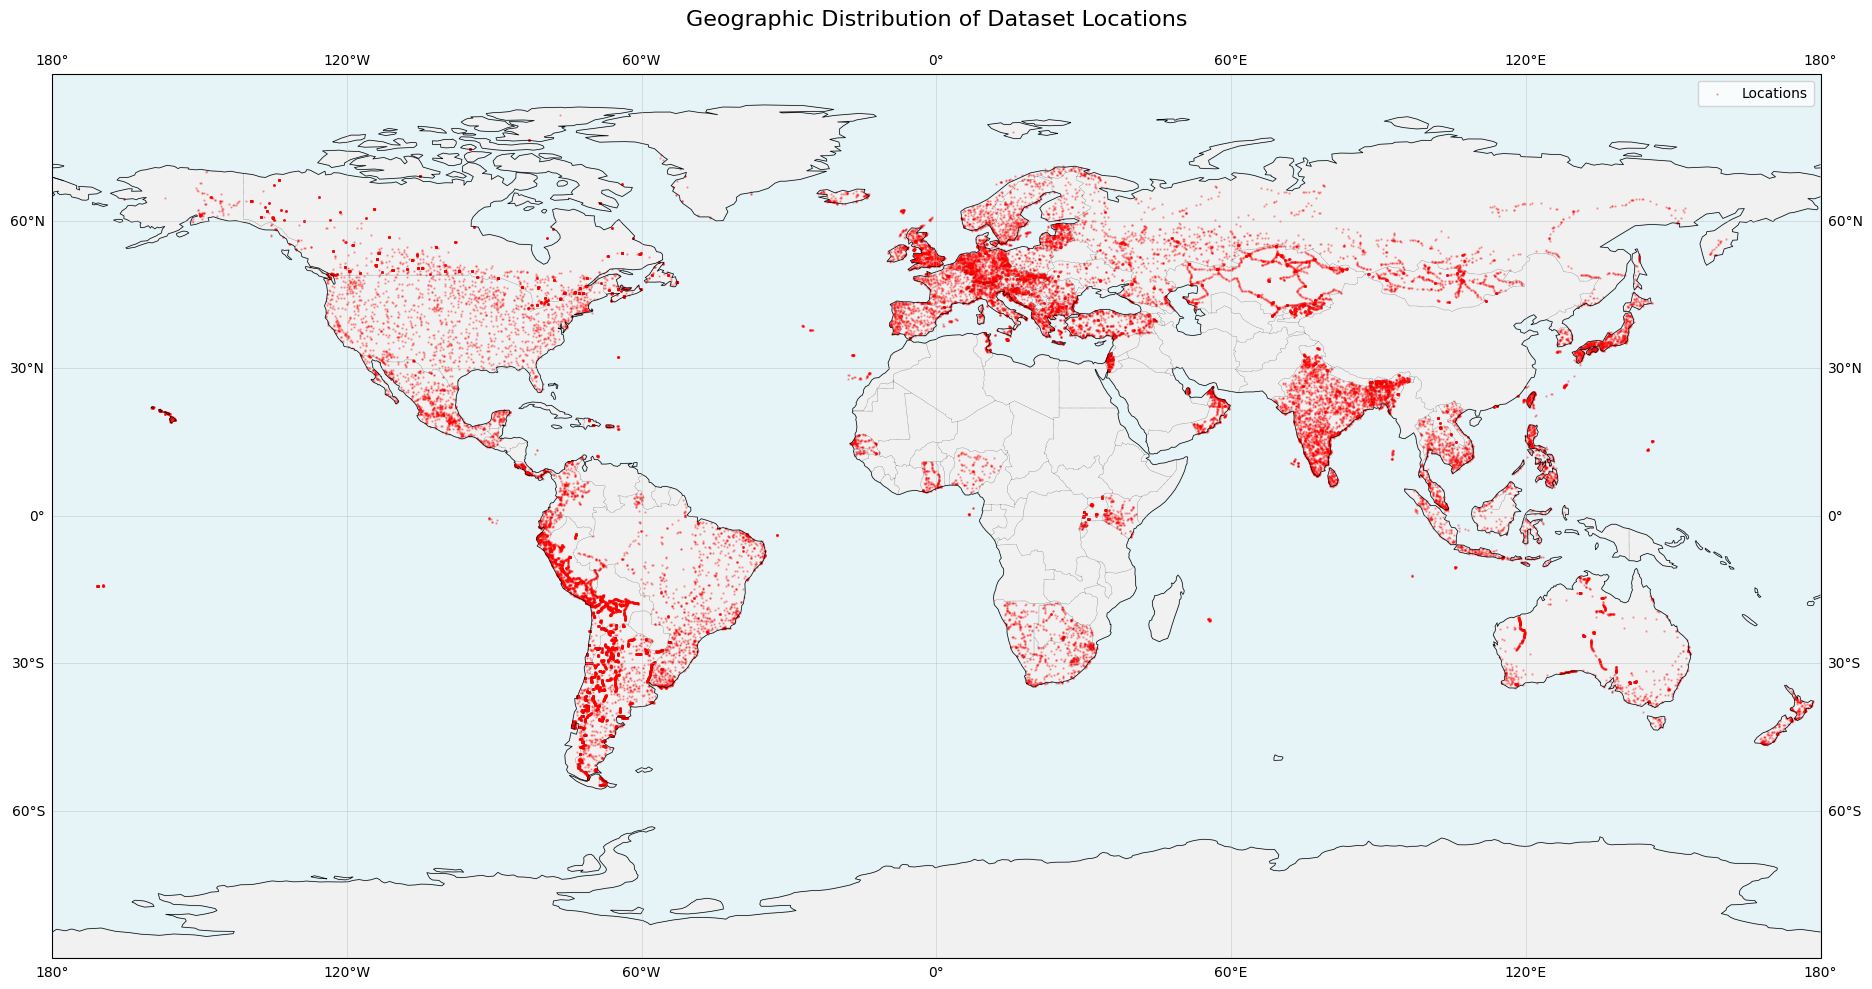

In [3]:
if HAS_CARTOPY:
    # Create figure with map projection
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.3, color='lightblue')
    
    # Plot locations (sample if too many for performance)
    if len(lats) > 50000:
        print(f"Sampling {50000} locations for visualization...")
        indices = np.random.choice(len(lats), 50000, replace=False)
        ax.scatter(lngs[indices], lats[indices], 
                  s=0.5, alpha=0.3, c='red', 
                  transform=ccrs.PlateCarree(),
                  label='Locations')
    else:
        ax.scatter(lngs, lats, 
                  s=0.5, alpha=0.3, c='red', 
                  transform=ccrs.PlateCarree(),
                  label='Locations')
    
    # Set global extent
    ax.set_global()
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    
    plt.title('Geographic Distribution of Dataset Locations', fontsize=16, pad=20)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: Simple scatter plot
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Sample if too many for performance
    if len(lats) > 50000:
        print(f"Sampling {50000} locations for visualization...")
        indices = np.random.choice(len(lats), 50000, replace=False)
        ax.scatter(lngs[indices], lats[indices], s=0.5, alpha=0.3, c='red')
    else:
        ax.scatter(lngs, lats, s=0.5, alpha=0.3, c='red')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Geographic Distribution of Dataset Locations', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()


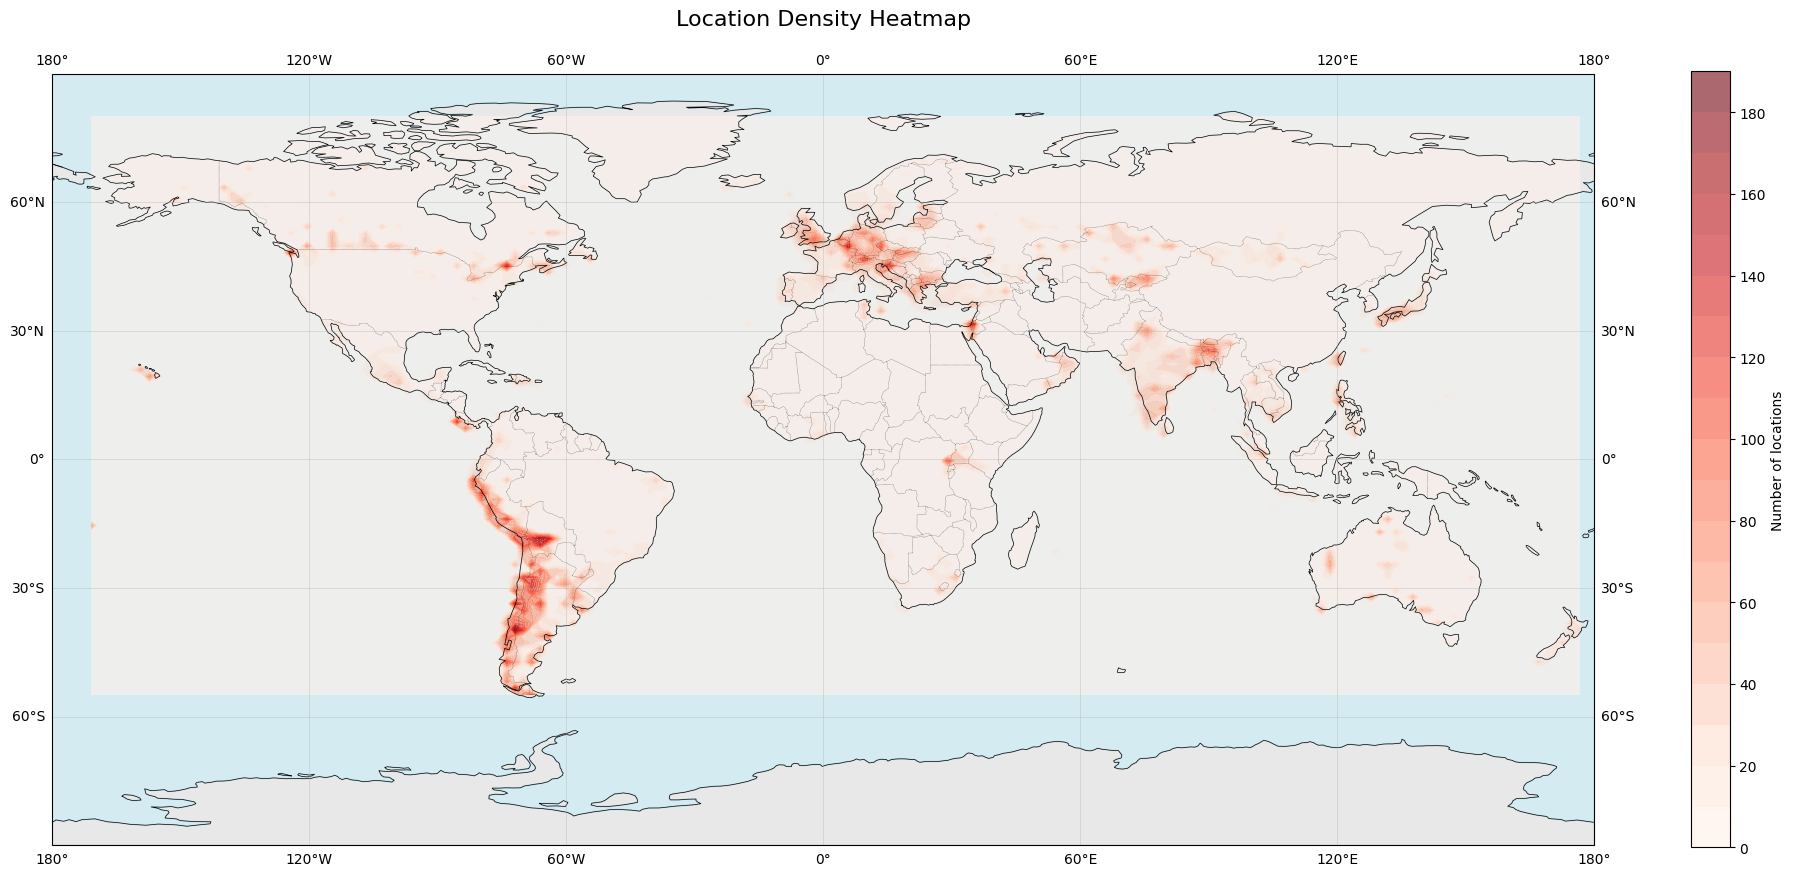

In [4]:
# Alternative: Density heatmap
if HAS_CARTOPY:
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.5, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.5, color='lightblue')
    
    # Create 2D histogram for density
    hist, xedges, yedges = np.histogram2d(lngs, lats, bins=[180, 90])
    
    # Plot heatmap
    im = ax.contourf(xedges[:-1], yedges[:-1], hist.T, 
                     levels=20, cmap='Reds', alpha=0.6,
                     transform=ccrs.PlateCarree())
    
    plt.colorbar(im, ax=ax, label='Number of locations', shrink=0.8)
    ax.set_global()
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    
    plt.title('Location Density Heatmap', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: Simple 2D histogram
    fig, ax = plt.subplots(figsize=(20, 10))
    
    hist, xedges, yedges = np.histogram2d(lngs, lats, bins=[180, 90])
    im = ax.contourf(xedges[:-1], yedges[:-1], hist.T, levels=20, cmap='Reds')
    plt.colorbar(im, ax=ax, label='Number of locations')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Location Density Heatmap', fontsize=16)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()


In [5]:
# Statistics
print("Geographic Coverage Statistics:")
print(f"  Latitude range: {lats.min():.2f}° to {lats.max():.2f}°")
print(f"  Longitude range: {lngs.min():.2f}° to {lngs.max():.2f}°")
print(f"  Total locations: {len(lats):,}")
print(f"  Unique grid cells (1°x1°): {len(set(zip(np.floor(lats), np.floor(lngs)))):,}")


Geographic Coverage Statistics:
  Latitude range: -54.88° to 81.66°
  Longitude range: -170.83° to 178.41°
  Total locations: 42,536
  Unique grid cells (1°x1°): 5,359


In [6]:
# Calculate centroids per concept
concept_centroids = df_clean.groupby('meta_name').agg({
    'lat': 'mean',
    'lng': 'mean',
    'pano_id': 'count'  # Count samples per concept
}).reset_index()
concept_centroids.columns = ['concept', 'centroid_lat', 'centroid_lng', 'sample_count']

print(f"Total concepts: {len(concept_centroids)}")
print(f"Concepts with samples: {concept_centroids['sample_count'].sum():,}")
print(f"\nTop 10 concepts by sample count:")
print(concept_centroids.nlargest(10, 'sample_count')[['concept', 'sample_count']].to_string(index=False))

Total concepts: 6550
Concepts with samples: 42,536

Top 10 concepts by sample count:
      concept  sample_count
    Roadlines           371
      Bollard           236
           95           219
        Vibes           218
         RN14           217
     Bollards           192
   Unique car           183
 RP55 & RN148           173
Chiloé Island           146
          RN3           144


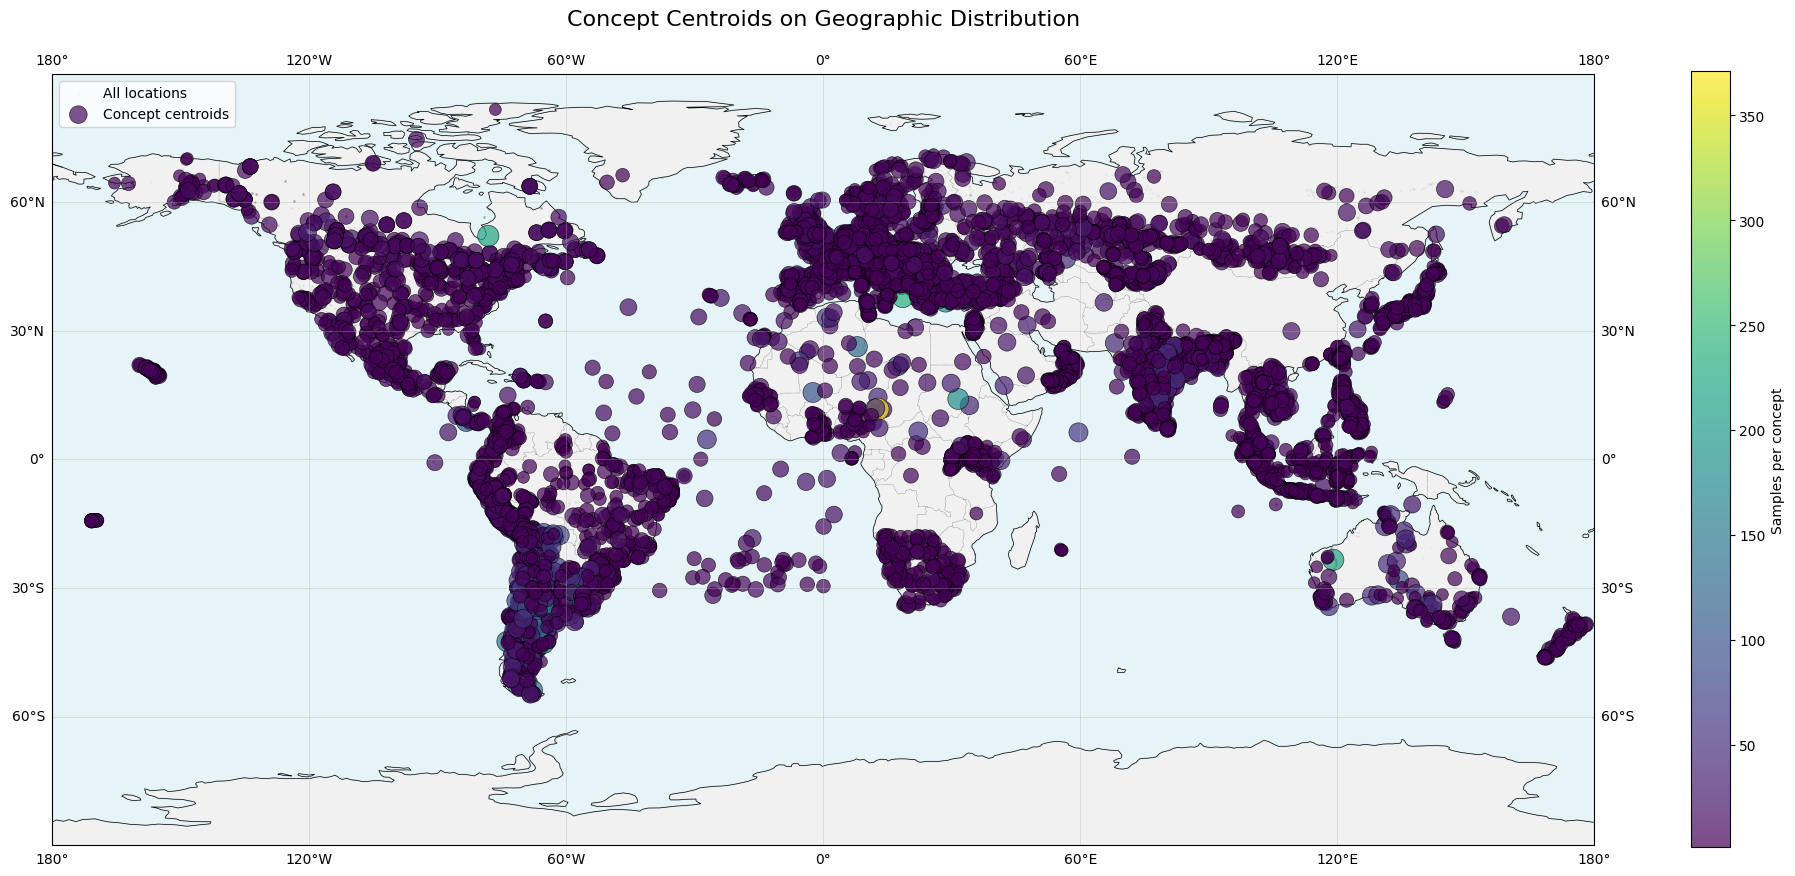

In [7]:
# Plot map with concept centroids
if HAS_CARTOPY:
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.3, color='lightblue')
    
    # Plot all locations (light, semi-transparent)
    if len(lats) > 50000:
        indices = np.random.choice(len(lats), 50000, replace=False)
        ax.scatter(lngs[indices], lats[indices], 
                  s=0.3, alpha=0.1, c='gray', 
                  transform=ccrs.PlateCarree(),
                  label='All locations', zorder=1)
    else:
        ax.scatter(lngs, lats, 
                  s=0.3, alpha=0.1, c='gray', 
                  transform=ccrs.PlateCarree(),
                  label='All locations', zorder=1)
    
    # Plot concept centroids (colored by sample count)
    centroid_lats = concept_centroids['centroid_lat'].values
    centroid_lngs = concept_centroids['centroid_lng'].values
    sample_counts = concept_centroids['sample_count'].values
    
    # Color by sample count (log scale for better visualization)
    scatter = ax.scatter(centroid_lngs, centroid_lats, 
                        s=50 + 200 * np.log1p(sample_counts) / np.log1p(sample_counts.max()),
                        c=sample_counts, cmap='viridis', alpha=0.7,
                        transform=ccrs.PlateCarree(),
                        edgecolors='black', linewidths=0.5,
                        label='Concept centroids', zorder=2)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Samples per concept', shrink=0.8)
    
    # Set global extent
    ax.set_global()
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    
    plt.title('Concept Centroids on Geographic Distribution', fontsize=16, pad=20)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback: Simple scatter plot
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Plot all locations (light)
    if len(lats) > 50000:
        indices = np.random.choice(len(lats), 50000, replace=False)
        ax.scatter(lngs[indices], lats[indices], s=0.3, alpha=0.1, c='gray', label='All locations')
    else:
        ax.scatter(lngs, lats, s=0.3, alpha=0.1, c='gray', label='All locations')
    
    # Plot centroids
    centroid_lats = concept_centroids['centroid_lat'].values
    centroid_lngs = concept_centroids['centroid_lng'].values
    sample_counts = concept_centroids['sample_count'].values
    
    scatter = ax.scatter(centroid_lngs, centroid_lats, 
                        s=50 + 200 * np.log1p(sample_counts) / np.log1p(sample_counts.max()),
                        c=sample_counts, cmap='viridis', alpha=0.7,
                        edgecolors='black', linewidths=0.5,
                        label='Concept centroids')
    
    plt.colorbar(scatter, ax=ax, label='Samples per concept')
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Concept Centroids on Geographic Distribution', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.legend()
    plt.tight_layout()
    plt.show()

Concepts with >= 5 samples: 2804
Total samples in filtered concepts: 33,655

Top 20 filtered concepts:
          concept  sample_count
        Roadlines           371
          Bollard           236
               95           219
            Vibes           218
             RN14           217
         Bollards           192
       Unique car           183
     RP55 & RN148           173
    Chiloé Island           146
              RN3           144
             RN40           141
           Ruta 9           129
         Chevrons           127
      RN3 (paved)           127
             RP30           127
              RP1           123
RN40 in Catamarca           110
            RN237           108
   License Plates           100
     Cerro Nevado            99

Locations for filtered concepts: 33,655


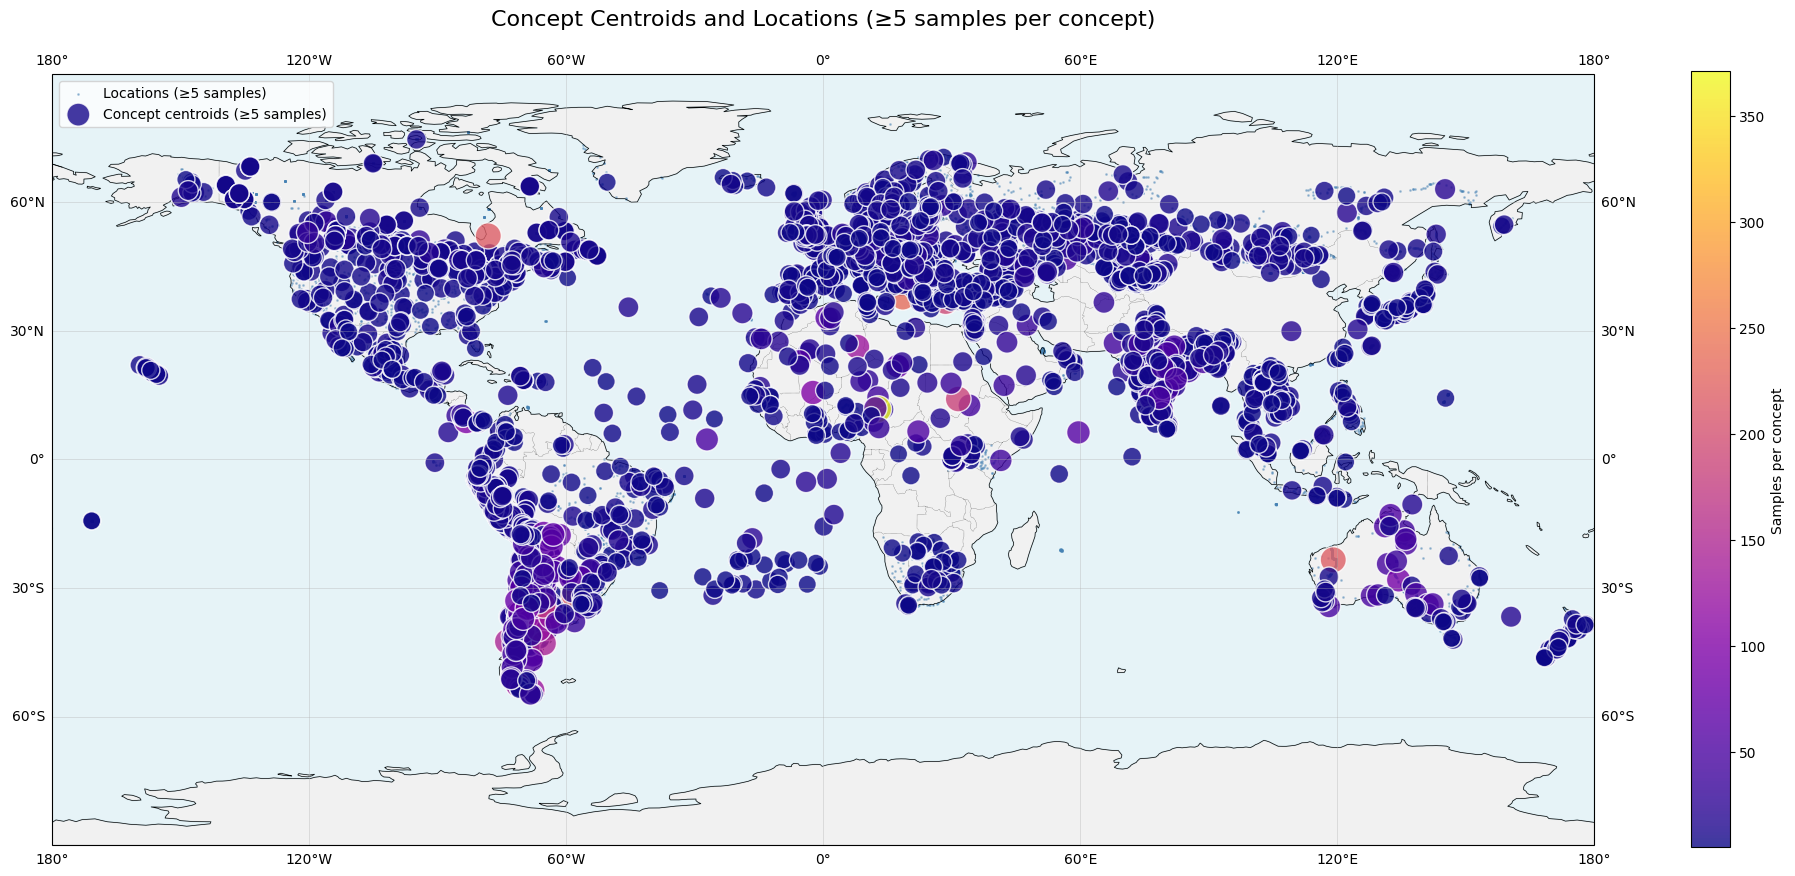

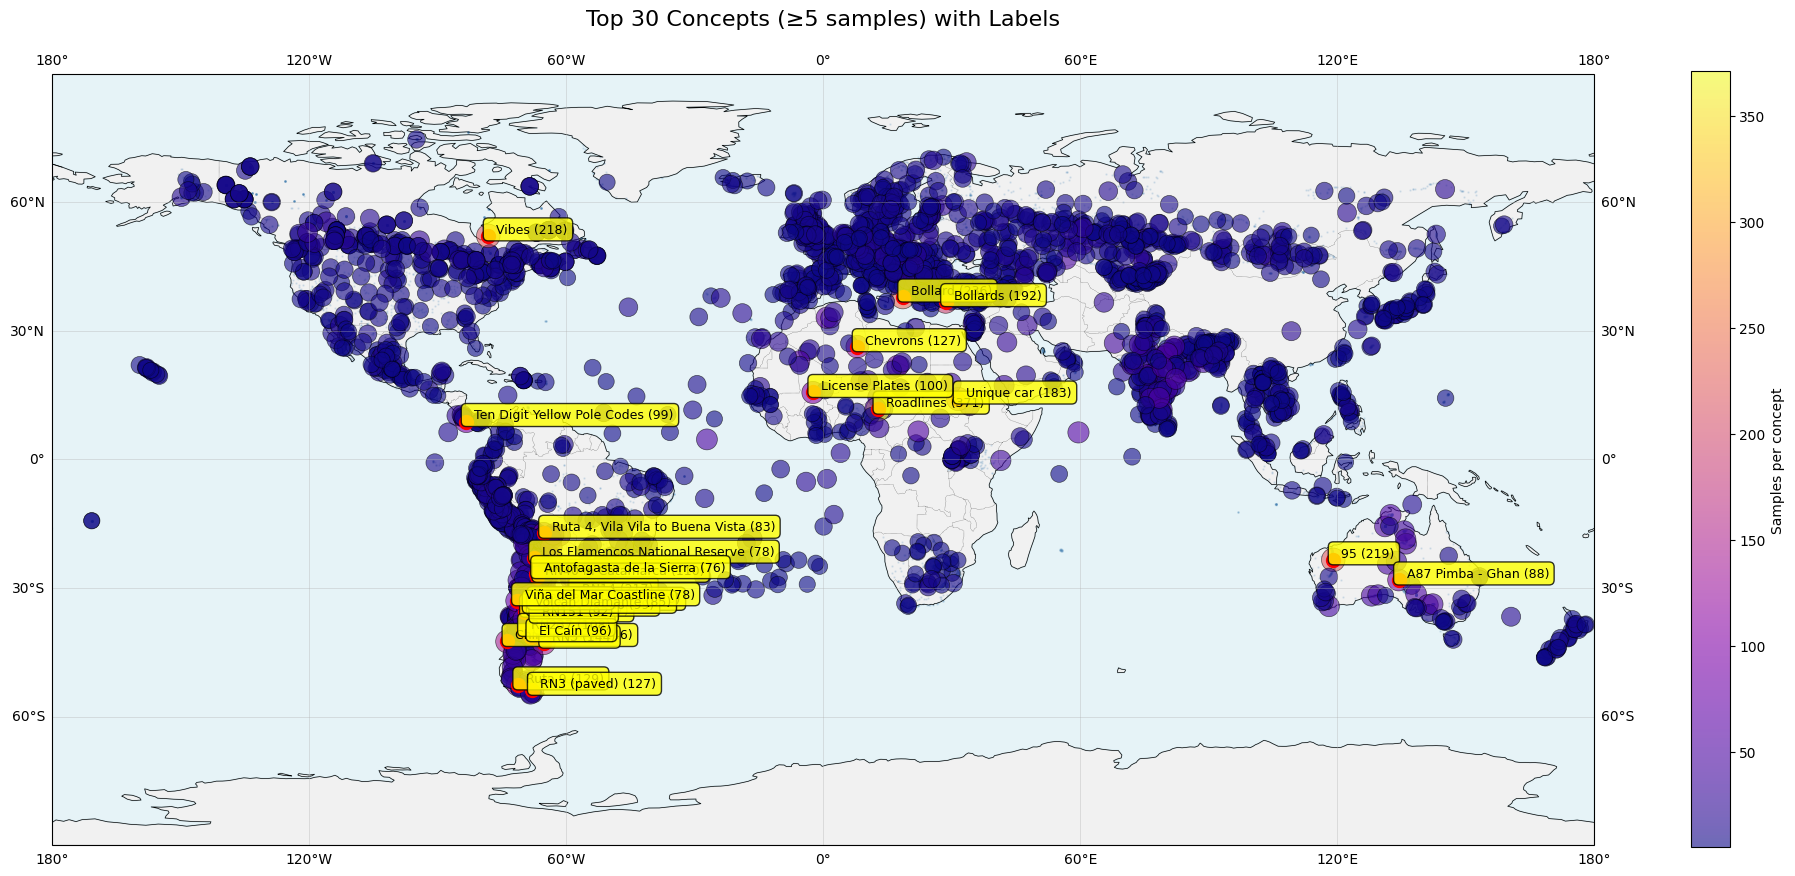

In [12]:
# Optional: Labeled visualization of filtered concepts (top N)
if HAS_CARTOPY:
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=':')
    ax.add_feature(cfeature.LAND, alpha=0.3, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.3, color='lightblue')
    
    # Plot filtered locations (light)
    if len(filtered_lats) > 50000:
        indices = np.random.choice(len(filtered_lats), 50000, replace=False)
        ax.scatter(filtered_lngs[indices], filtered_lats[indices], 
                  s=0.5, alpha=0.15, c='steelblue', 
                  transform=ccrs.PlateCarree(), zorder=1)
    else:
        ax.scatter(filtered_lngs, filtered_lats, 
                  s=0.5, alpha=0.15, c='steelblue', 
                  transform=ccrs.PlateCarree(), zorder=1)
    
    # Plot all filtered centroids
    filtered_centroid_lats = filtered_centroids['centroid_lat'].values
    filtered_centroid_lngs = filtered_centroids['centroid_lng'].values
    filtered_sample_counts = filtered_centroids['sample_count'].values
    
    scatter = ax.scatter(filtered_centroid_lngs, filtered_centroid_lats, 
                        s=60 + 250 * np.log1p(filtered_sample_counts) / np.log1p(filtered_sample_counts.max()),
                        c=filtered_sample_counts, cmap='plasma', alpha=0.6,
                        transform=ccrs.PlateCarree(),
                        edgecolors='black', linewidths=0.5, zorder=2)
    
    # Label top N concepts
    top_n = 30
    top_filtered = filtered_centroids.nlargest(top_n, 'sample_count')
    
    for _, row in top_filtered.iterrows():
        ax.plot(row['centroid_lng'], row['centroid_lat'], 
               'ro', markersize=10, transform=ccrs.PlateCarree(), zorder=3)
        ax.text(row['centroid_lng'], row['centroid_lat'], 
               f"  {row['concept']} ({row['sample_count']})", 
               transform=ccrs.PlateCarree(),
               fontsize=9, ha='left', va='bottom',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8, edgecolor='black'),
               zorder=4)
    
    plt.colorbar(scatter, ax=ax, label='Samples per concept', shrink=0.8)
    ax.set_global()
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    
    plt.title(f'Top {top_n} Concepts (≥{min_samples} samples) with Labels', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
else:
    # Fallback version
    fig, ax = plt.subplots(figsize=(20, 10))
    
    # Plot filtered locations
    if len(filtered_lats) > 50000:
        indices = np.random.choice(len(filtered_lats), 50000, replace=False)
        ax.scatter(filtered_lngs[indices], filtered_lats[indices], s=0.5, alpha=0.15, c='steelblue')
    else:
        ax.scatter(filtered_lngs, filtered_lats, s=0.5, alpha=0.15, c='steelblue')
    
    # Plot centroids
    filtered_centroid_lats = filtered_centroids['centroid_lat'].values
    filtered_centroid_lngs = filtered_centroids['centroid_lng'].values
    filtered_sample_counts = filtered_centroids['sample_count'].values
    
    scatter = ax.scatter(filtered_centroid_lngs, filtered_centroid_lats, 
                        s=60 + 250 * np.log1p(filtered_sample_counts) / np.log1p(filtered_sample_counts.max()),
                        c=filtered_sample_counts, cmap='plasma', alpha=0.6,
                        edgecolors='black', linewidths=0.5)
    
    # Label top N
    top_n = 30
    top_filtered = filtered_centroids.nlargest(top_n, 'sample_count')
    
    for _, row in top_filtered.iterrows():
        ax.plot(row['centroid_lng'], row['centroid_lat'], 'ro', markersize=10)
        ax.text(row['centroid_lng'], row['centroid_lat'], 
               f"  {row['concept']} ({row['sample_count']})", 
               fontsize=9, ha='left', va='bottom',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.8, edgecolor='black'))
    
    plt.colorbar(scatter, ax=ax, label='Samples per concept')
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title(f'Top {top_n} Concepts (≥{min_samples} samples) with Labels', fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()
